In [ ]:
clear all;

n_1=1.531-i*0.002; % комплексный показатель преломления призмы (Zeonex)
eps_1=n_1.^2; % диэлектрическая проницаемость призмы (Zeonex)
eps_2=1; % диэлектрическая проницаемость воздуха

%Параметры InSb в модели Друде Лоренца
wp=0.578*10^14; %плазменная частота (рад/с)
gp=1/5.16*10^13; %частота столкновений (рад/с)
wl=3.4*10^13; %частота Лоренца (рад/с)
gl=1/1.5*10^12; %Лоренцева частота столкновений (рад/с)
Al=2.02; %Амплитуда в модели Лоренца
eps0=15.86; %диэлектрическая проницаемость на бесконечности

wavelength=130*10.^(-6); %длина волны излучения
f=3*10^8/wavelength; %частота излучения
w=6.28*f; %круговая частота

%Модель Друде-Лоренца для проницаемости InSb
eps_3=eps0-wp.^2/(w.^2+i*gp*w)+Al*wl.^2/(wl^2-w.^2-i*gl*w);

d_2=0*10^(-6): 1*10^(-6):600*10^(-6); %величина зазора между призмой и InSb
teta_ext=40.44; %внешний угол падения излучения на призму

teta=45*pi/180-asin(sin((45-teta_ext)*pi/180)/real(n_1)); %угол падения в призме

% f=1.5*10^12:0.01*10^12:2*10^12;
% w=6.28*f;
% 
% %Модель Друде-Лоренца для проницаемости InSb
% for j=1:1:length(w)
%     eps(j)=eps0-wp.^2/(w(j).^2+i*gp*w(j))+Al*wl.^2/(wl^2-w(j).^2-i*gl*w(j));
% end;
% plot (f, real(eps), f, imag(eps));

%----------------------------------

%Нормальные компоненты волновых векторов (нормированные на k0)
kz_1=sqrt(eps_1)*cos(teta);
kz_2=sqrt(eps_2-eps_1*sin(teta).^2);
kz_3=sqrt(eps_3-eps_1*sin(teta).^2);

%Коэффициенты отражения
r_12=(eps_2*kz_1-eps_1*kz_2)/(eps_2*kz_1+eps_1*kz_2);
r_23=(eps_3*kz_2-eps_2*kz_3)/(eps_3*kz_2+eps_2*kz_3);

%Коэффициенты пропускания
t_12=2*kz_1*sqrt(eps_1*eps_2)/(eps_2*kz_1+eps_1*kz_2); %???
t_23=2*kz_2*sqrt(eps_2*eps_3)/(eps_3*kz_2+eps_2*kz_3);

%Матрица преобразования
S1=[1/t_12 r_12/t_12; r_12/t_12 1/t_12];

for j=1:1:length(d_2)
    S2=[exp(-i*(2*pi/wavelength)*kz_2*d_2(j))/t_23 r_23*exp(-i*(2*pi/wavelength)*kz_2*d_2(j))/t_23; r_23*exp(i*(2*pi/wavelength)*kz_2*d_2(j))/t_23 exp(i*(2*pi/wavelength)*kz_2*d_2(j))/t_23];
    S=S1*S2;
    R(j)=abs(S(2,1)/S(1,1)).^2;
end;

plot(d_2*10^6, R);

Data=[d_2*10^6; R];

fileID = fopen('R_spp_InSb_195 um_teta-42.16.txt','w');
fprintf(fileID,'%6s %18s\n','d','R_spp');
fprintf(fileID,'%e\t%e\n',Data);
fclose(fileID);




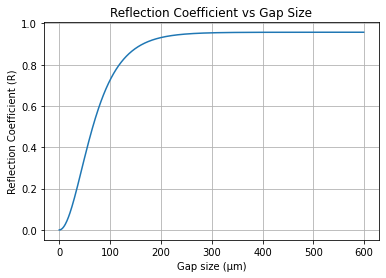

In [1]:
import numpy as np
import matplotlib.pyplot as plt

n_1 = 1.531 - 1j * 0.002  # Complex refractive index of the prism (Zeonex)
eps_1 = n_1**2  # Dielectric permittivity of the prism (Zeonex)
eps_2 = 1  # Dielectric permittivity of air

# Parameters for InSb in the Drude-Lorentz model
wp = 0.578 * 10**14  # Plasma frequency (rad/s)
gp = 1 / (5.16 * 10**13)  # Collision frequency (rad/s)
wl = 3.4 * 10**13  # Lorentz frequency (rad/s)
gl = 1 / (1.5 * 10**12)  # Lorentz collision frequency (rad/s)
Al = 2.02  # Amplitude in the Lorentz model
eps0 = 15.86  # Dielectric permittivity at infinity

wavelength = 130 * 10**(-6)  # Wavelength of radiation
f = 3 * 10**8 / wavelength  # Frequency of radiation
w = 2 * np.pi * f  # Angular frequency

# Drude-Lorentz model for the permittivity of InSb
eps_3 = eps0 - wp**2 / (w**2 + 1j * gp * w) + Al * wl**2 / (wl**2 - w**2 - 1j * gl * w)

d_2 = np.arange(0, 600 * 10**(-6), 1 * 10**(-6))  # Gap size between the prism and InSb
teta_ext = 40.44  # External angle of incidence on the prism

# Calculate the angle of incidence in the prism
teta = 45 * np.pi / 180 - np.arcsin(np.sin((45 - teta_ext) * np.pi / 180) / np.real(n_1))

# Normal components of wave vectors (normalized by k0)
kz_1 = np.sqrt(eps_1) * np.cos(teta)
kz_2 = np.sqrt(eps_2 - eps_1 * np.sin(teta)**2)
kz_3 = np.sqrt(eps_3 - eps_1 * np.sin(teta)**2)

# Reflection coefficients
r_12 = (eps_2 * kz_1 - eps_1 * kz_2) / (eps_2 * kz_1 + eps_1 * kz_2)
r_23 = (eps_3 * kz_2 - eps_2 * kz_3) / (eps_3 * kz_2 + eps_2 * kz_3)

# Transmission coefficients
t_12 = 2 * kz_1 * np.sqrt(eps_1 * eps_2) / (eps_2 * kz_1 + eps_1 * kz_2)
t_23 = 2 * kz_2 * np.sqrt(eps_2 * eps_3) / (eps_3 * kz_2 + eps_2 * kz_3)

# Transformation matrix
S1 = np.array([[1 / t_12, r_12 / t_12], [r_12 / t_12, 1 / t_12]])

R = np.zeros(len(d_2))  # Initialize reflection coefficient array

for j in range(len(d_2)):
    S2 = np.array([[np.exp(-1j * (2 * np.pi / wavelength) * kz_2 * d_2[j]) / t_23,
                    r_23 * np.exp(-1j * (2 * np.pi / wavelength) * kz_2 * d_2[j]) / t_23],
                   [r_23 * np.exp(1j * (2 * np.pi / wavelength) * kz_2 * d_2[j]) / t_23,
                    np.exp(1j * (2 * np.pi / wavelength) * kz_2 * d_2[j]) / t_23]])
    
    S = np.dot(S1, S2)
    R[j] = np.abs(S[1, 0] / S[0, 0])**2

# Plot the results
plt.plot(d_2 * 10**6, R)  # Convert d_2 to micrometers for plotting
plt.xlabel('Gap size (µm)')
plt.ylabel('Reflection Coefficient (R)')
plt.title('Reflection Coefficient vs Gap Size')
plt.grid()
plt.show()

# Save data to a text file
Data = np.vstack((d_2 * 10**6, R)).T  # Transpose to match format
np.savetxt('R_spp_InSb_195_um_teta-42.16.txt', Data, header='d R_spp', fmt='%6s %18s', delimiter='\t', comments='')

In [ ]:
clear all;

eps_0=8.85*10^(-12); %Электрическая постоянная
n_1=1.531-i*0.002; % комплексный показатель преломления призмы (Zeonex)
eps_1=n_1.^2; % диэлектрическая проницаемость призмы (Zeonex)
eps_2=1; % диэлектрическая проницаемость воздуха
eps_3=-14+i*700; % диэлектрическая проницаемость тонкого слоя диэлектрика на InSb 940-i*260 -15+i*700


%Параметры InSb в модели Друде Лоренца
wp=0.578*10^14; %плазменная частота (рад/с)
gp=1/5.16*10^13; %частота столкновений (рад/с)
wl=3.4*10^13; %частота Лоренца (рад/с)
gl=1/3*10^12; %Лоренцева частота столкновений (рад/с)
Al=2.02; %Амплитуда в модели Лоренца
eps0=15.86; %диэлектрическая проницаемость на бесконечности

wavelength=197*10.^(-6); %длина волны излучения
f=3*10^8/wavelength; %частота излучения
w=6.28*f; %круговая частота

%Модель Друде-Лоренца для проницаемости InSb
eps_4=eps0-wp.^2/(w.^2+i*gp*w)+Al*wl.^2/(wl^2-w.^2-i*gl*w);

%Ьодель друде для графена
d_3=35*10^(-9); %Толщина исследуемого слоя
% sigma_0=100.5*0.3*10^(-3); %Проводимость по постояному току
% tau=50*10^(-15);
% sigma=sigma_0/(1-i*w*tau);
% eps_3=1+i*sigma/(eps_0*w*d_3);

d_2=0*10^(-6):1*10^(-6):450*10^(-6); %величина зазора между призмой и InSb


teta_ext=40.7; %внешний угол падения излучения на призму

teta=45*pi/180-asin(sin((45-teta_ext)*pi/180)/real(n_1)); %угол падения в призме



% f=1.5*10^12:0.01*10^12:2*10^12;
% w=6.28*f;
% 
% %Модель Друде-Лоренца для проницаемости InSb
% for j=1:1:length(w)
%     eps(j)=eps0-wp.^2/(w(j).^2+i*gp*w(j))+Al*wl.^2/(wl^2-w(j).^2-i*gl*w(j));
% end;
% plot (f, real(eps), f, imag(eps));

%----------------------------------

%Нормальные компоненты волновых векторов (нормированные на k0)
kz_1=sqrt(eps_1)*cos(teta);
kz_2=sqrt(eps_2-eps_1*sin(teta).^2);
kz_3=sqrt(eps_3-eps_1*sin(teta).^2);
kz_4=sqrt(eps_4-eps_1*sin(teta).^2);

%Коэффициенты отражения
r_12=(eps_2*kz_1-eps_1*kz_2)/(eps_2*kz_1+eps_1*kz_2);
r_23=(eps_3*kz_2-eps_2*kz_3)/(eps_3*kz_2+eps_2*kz_3);
r_34=(eps_4*kz_3-eps_3*kz_4)/(eps_4*kz_3+eps_3*kz_4);

%Коэффициенты пропускания
t_12=2*kz_1*sqrt(eps_1*eps_2)/(eps_2*kz_1+eps_1*kz_2); %???
t_23=2*kz_2*sqrt(eps_2*eps_3)/(eps_3*kz_2+eps_2*kz_3);
t_34=2*kz_3*sqrt(eps_3*eps_4)/(eps_4*kz_3+eps_3*kz_4);

%Матрица преобразования
S1=[1/t_12 r_12/t_12; r_12/t_12 1/t_12];
S3=[exp(-i*(2*pi/wavelength)*kz_3*d_3)/t_34 r_34*exp(-i*(2*pi/wavelength)*kz_3*d_3)/t_34; r_34*exp(i*(2*pi/wavelength)*kz_3*d_3)/t_34 exp(i*(2*pi/wavelength)*kz_3*d_3)/t_34];

for j=1:1:length(d_2)
    S2=[exp(-i*(2*pi/wavelength)*kz_2*d_2(j))/t_23 r_23*exp(-i*(2*pi/wavelength)*kz_2*d_2(j))/t_23; r_23*exp(i*(2*pi/wavelength)*kz_2*d_2(j))/t_23 exp(i*(2*pi/wavelength)*kz_2*d_2(j))/t_23];
    S=S1*S2*S3;
    R(j)=abs(S(2,1)/S(1,1)).^2;
end;

plot((d_2-d_3)*10^6, R);

Data=[(d_2-d_3)*10^6; R];

fileID = fopen('R_spp_InSb-PMMA_195 um_teta-42.21.dat','w');
fprintf(fileID,'%6s %18s\n','d','R_spp');
fprintf(fileID,'%e\t%e\n',Data);
fclose(fileID);




In [ ]:
clear all;

eps_0=8.85*10^(-12); %Электрическая постоянная
n_1=1.531-i*0.002; % комплексный показатель преломления призмы (Zeonex)
eps_1=n_1.^2; % диэлектрическая проницаемость призмы (Zeonex)
eps_2=1; % диэлектрическая проницаемость воздуха
eps_3=-14+i*700; % диэлектрическая проницаемость тонкого слоя диэлектрика на InSb 940-i*260 -15+i*700


%Параметры InSb в модели Друде Лоренца
wp=0.578*10^14; %плазменная частота (рад/с)
gp=1/5.16*10^13; %частота столкновений (рад/с)
wl=3.4*10^13; %частота Лоренца (рад/с)
gl=1/3*10^12; %Лоренцева частота столкновений (рад/с)
Al=2.02; %Амплитуда в модели Лоренца
eps0=15.86; %диэлектрическая проницаемость на бесконечности

wavelength=197*10.^(-6); %длина волны излучения
f=3*10^8/wavelength; %частота излучения
w=6.28*f; %круговая частота

%Модель Друде-Лоренца для проницаемости InSb
eps_4=eps0-wp.^2/(w.^2+i*gp*w)+Al*wl.^2/(wl^2-w.^2-i*gl*w);

%Ьодель друде для графена
d_3=35*10^(-9); %Толщина исследуемого слоя
% sigma_0=100.5*0.3*10^(-3); %Проводимость по постояному току
% tau=50*10^(-15);
% sigma=sigma_0/(1-i*w*tau);
% eps_3=1+i*sigma/(eps_0*w*d_3);

d_2=0*10^(-6):1*10^(-6):450*10^(-6); %величина зазора между призмой и InSb


teta_ext=40.7; %внешний угол падения излучения на призму

teta=45*pi/180-asin(sin((45-teta_ext)*pi/180)/real(n_1)); %угол падения в призме



% f=1.5*10^12:0.01*10^12:2*10^12;
% w=6.28*f;
% 
% %Модель Друде-Лоренца для проницаемости InSb
% for j=1:1:length(w)
%     eps(j)=eps0-wp.^2/(w(j).^2+i*gp*w(j))+Al*wl.^2/(wl^2-w(j).^2-i*gl*w(j));
% end;
% plot (f, real(eps), f, imag(eps));

%----------------------------------

%Нормальные компоненты волновых векторов (нормированные на k0)
kz_1=sqrt(eps_1)*cos(teta);
kz_2=sqrt(eps_2-eps_1*sin(teta).^2);
kz_3=sqrt(eps_3-eps_1*sin(teta).^2);
kz_4=sqrt(eps_4-eps_1*sin(teta).^2);

%Коэффициенты отражения
r_12=(eps_2*kz_1-eps_1*kz_2)/(eps_2*kz_1+eps_1*kz_2);
r_23=(eps_3*kz_2-eps_2*kz_3)/(eps_3*kz_2+eps_2*kz_3);
r_34=(eps_4*kz_3-eps_3*kz_4)/(eps_4*kz_3+eps_3*kz_4);

%Коэффициенты пропускания
t_12=2*kz_1*sqrt(eps_1*eps_2)/(eps_2*kz_1+eps_1*kz_2); %???
t_23=2*kz_2*sqrt(eps_2*eps_3)/(eps_3*kz_2+eps_2*kz_3);
t_34=2*kz_3*sqrt(eps_3*eps_4)/(eps_4*kz_3+eps_3*kz_4);

%Матрица преобразования
S1=[1/t_12 r_12/t_12; r_12/t_12 1/t_12];
S3=[exp(-i*(2*pi/wavelength)*kz_3*d_3)/t_34 r_34*exp(-i*(2*pi/wavelength)*kz_3*d_3)/t_34; r_34*exp(i*(2*pi/wavelength)*kz_3*d_3)/t_34 exp(i*(2*pi/wavelength)*kz_3*d_3)/t_34];

for j=1:1:length(d_2)
    S2=[exp(-i*(2*pi/wavelength)*kz_2*d_2(j))/t_23 r_23*exp(-i*(2*pi/wavelength)*kz_2*d_2(j))/t_23; r_23*exp(i*(2*pi/wavelength)*kz_2*d_2(j))/t_23 exp(i*(2*pi/wavelength)*kz_2*d_2(j))/t_23];
    S=S1*S2*S3;
    R(j)=abs(S(2,1)/S(1,1)).^2;
end;

plot((d_2-d_3)*10^6, R);

Data=[(d_2-d_3)*10^6; R];

fileID = fopen('R_spp_InSb-PMMA_195 um_teta-42.21.dat','w');
fprintf(fileID,'%6s %18s\n','d','R_spp');
fprintf(fileID,'%e\t%e\n',Data);
fclose(fileID);




In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Clear all variables (not needed in Python)

eps_0 = 8.85 * 10**(-12)  # Electric constant
n_1 = 1.531 - 1j * 0.002  # Complex refractive index of the prism (Zeonex)
eps_1 = n_1**2  # Dielectric permittivity of the prism (Zeonex)
eps_2 = 1  # Dielectric permittivity of air
eps_3 = -14 + 1j * 700  # Dielectric permittivity of the thin dielectric layer on InSb

# Parameters for InSb in the Drude-Lorentz model
wp = 0.578 * 10**14  # Plasma frequency (rad/s)
gp = 1 / (5.16 * 10**13)  # Collision frequency (rad/s)
wl = 3.4 * 10**13  # Lorentz frequency (rad/s)
gl = 1 / (3 * 10**12)  # Lorentz collision frequency (rad/s)
Al = 2.02  # Amplitude in the Lorentz model
eps0 = 15.86  # Dielectric permittivity at infinity

wavelength = 197 * 10**(-6)  # Wavelength of radiation
f = 3 * 10**8 / wavelength  # Frequency of radiation
w = 2 * np.pi * f  # Angular frequency

# Drude-Lorentz model for the permittivity of InSb
eps_4 = eps0 - wp**2 / (w**2 + 1j * gp * w) + Al * wl**2 / (wl**2 - w**2 - 1j * gl * w)

# Parameters for the graphene model
d_3 = 35 * 10**(-9)  # Thickness of the studied layer

d_2 = np.arange(0, 450 * 10**(-6), 1 * 10**(-6))  # Gap size between the prism and InSb

teta_ext = 40.7  # External angle of incidence on the prism

# Calculate the angle of incidence in the prism
teta = 45 * np.pi / 180 - np.arcsin(np.sin((45 - teta_ext) * np.pi / 180) / np.real(n_1))

# Normal components of wave vectors (normalized by k0)
kz_1 = np.sqrt(eps_1) * np.cos(teta)
kz_2 = np.sqrt(eps_2 - eps_1 * np.sin(teta)**2)
kz_3 = np.sqrt(eps_3 - eps_1 * np.sin(teta)**2)
kz_4 = np.sqrt(eps_4 - eps_1 * np.sin(teta)**2)

# Reflection coefficients
r_12 = (eps_2 * kz_1 - eps_1 * kz_2) / (eps_2 * kz_1 + eps_1 * kz_2)
r_23 = (eps_3 * kz_2 - eps_2 * kz_3) / (eps_3 * kz_2 + eps_2 * kz_3)
r_34 = (eps_4 * kz_3 - eps_3 * kz_4) / (eps_4 * kz_3 + eps_3 * kz_4)

# Transmission coefficients
t_12 = 2 * kz_1 * np.sqrt(eps_1 * eps_2) / (eps_2 * kz_1 + eps_1 * kz_2)
t_23 = 2 * kz_2 * np.sqrt(eps_2 * eps_3) / (eps_3 * kz_2 + eps_2 * kz_3)
t_34 = 2 * kz_3 * np.sqrt(eps_3 * eps_4) / (eps_4 * kz_3 + eps_3 * kz_4)

# Transformation matrices
S1 = np.array([[1 / t_12, r_12 / t_12], [r_12 / t_12, 1 / t_12]])
S3 = np.array([[np.exp(-1j * (2 * np.pi / wavelength) * kz_3 * d_3) / t_34,
                 r_34 * np.exp(-1j * (2 * np.pi / wavelength) * kz_3 * d_3) / t_34],
                [r_34 * np.exp(1j * (2 * np.pi / wavelength) * kz_3 * d_3) / t_34,
                 np.exp(1j * (2 * np.pi / wavelength) * kz_3 * d_3) / t_34]])

R = np.zeros(len(d_2))  # Initialize reflection coefficient array

for j in range(len(d_2)):
    S2 = np.array([[np.exp(-1j * (2 * np.pi / wavelength) * kz_2 * d_2[j]) / t_23,
                     r_23 * np.exp(-1j * (2 * np.pi / wavelength) * kz_2 * d_2[j]) / t_23],
                    [r_23 * np.exp(1j * (2 * np.pi / wavelength) * kz_2 * d_2[j]) / t_23,
                     np.exp(1j * (2 * np.pi / wavelength) * kz_2 * d_2[j]) / t_23]])
    
    S = S1 @ S2 @ S3  # Matrix multiplication
    R[j] = np.abs(S[1, 0] / S[0, 0])**2

# Plot the results
plt.plot((d_2 - d_3) * 10**6, R)  # Convert d_2 to micrometers for plotting
plt.xlabel('Gap size (µm)')
plt.ylabel('Reflection Coefficient (R)')
plt.title('Reflection Coefficient vs Gap Size')
plt.grid()
plt.show()

# Save data to a text file
Data = np.vstack(((d_2 - d_3) * 10**6, R)).T  # Transpose to match format
np.savetxt('R_spp_InSb-PMMA_195_um_teta-42.21.dat', Data, header='d R_spp', fmt='%6s %18s', delimiter='\t', comments='')